# 7.1.1 从有噪读数建立状态模型

## 学习目标与先修知识

区分状态（state）、过程噪声（process noise）和测量噪声（measurement noise），明确估计器能使用的信息。

先修：第3篇的状态向量（vector）与矩阵（matrix）转移、第5篇的方差（variance）和条件概率（conditional probability）。 [本篇学习次序](../README.md)。

## 具体问题

组织中第一室的读数下降，究竟是物质转移到了第二室，还是传感器低报？从一条读数推断内部过程，必须先区分系统怎样变化与仪器怎样测量。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
F=np.array([[.8,.2],[.2,.8]]);x=np.array([8.,2.]);H=np.array([1.,0.])
display(Markdown(show_table(['项目','数值'],[['初始状态',x.tolist()],['一步无噪状态',(F@x).tolist()],['低报0.5的读数',float(H@x-.5)]])))

| 项目 | 数值 |
| --- | --- |
| 初始状态 | [8.0, 2.0] |
| 一步无噪状态 | [6.800000000000001, 3.2] |
| 低报0.5的读数 | 7.5 |

## 模型假设

两个室内充分混合，以日为一步；状态是相对工作点的两项物质量偏差，单位U，可为负。矩阵F已知。过程噪声表示未解释的真实变化；测量噪声只进入仪器读数。以下小实验先给定噪声增量，不把它们作为估计器可获得的输入（input）。高斯扰动适合偏差近似，不保证绝对物质量非负；跨越零的大扰动需要更合适的状态模型（model）。

## 数学解释与推导

记 $x_t\in\mathbb R^2$，读数为标量 $y_t$：
$$x_{t+1}=F x_t+w_t,\qquad y_t=H x_t+v_t.$$
若噪声独立、均值为零，且协方差（covariance）分别为 $Q,R$，则
$$E[x_{t+1}]=F E[x_t],\quad \operatorname{Cov}(x_{t+1})=F P_tF^T+Q.$$
展开 $E[(F\delta x+w)(F\delta x+w)^T]$，独立零均值使两个交叉项为零。这也说明：把测量噪声错误加到状态里，会改变后续动态。

马尔可夫（Markov）性质（Markov property）限定 $p(x_{t+1}\mid x_{0:t})=p(x_{t+1}\mid x_t)$；条件观测（observation）独立限定 $p(y_t\mid x_{0:t},y_{0:t-1})=p(y_t\mid x_t)$。它们不意味着相邻状态或全部读数互相独立。参数（parameter）辨识（parameter identification）估计F等规则，状态估计（state estimation）在规则给定后推断当前x。

## 核心实现

下面按推导写出计算步骤；函数的输入只包含模型与当时可用的信息。

In [3]:
def state_path(transition, sensor, initial, process_noise, measurement_noise):
    """时刻0使用initial；第i行过程增量用于i到i+1。"""
    F, H = np.array(transition, float), np.array(sensor, float)
    states = [np.array(initial, float)]
    for increment in process_noise:
        states.append(F @ states[-1] + np.array(increment))
    states = np.array(states)
    return states.tolist(), (states @ H + measurement_noise).tolist()

## 对照实验

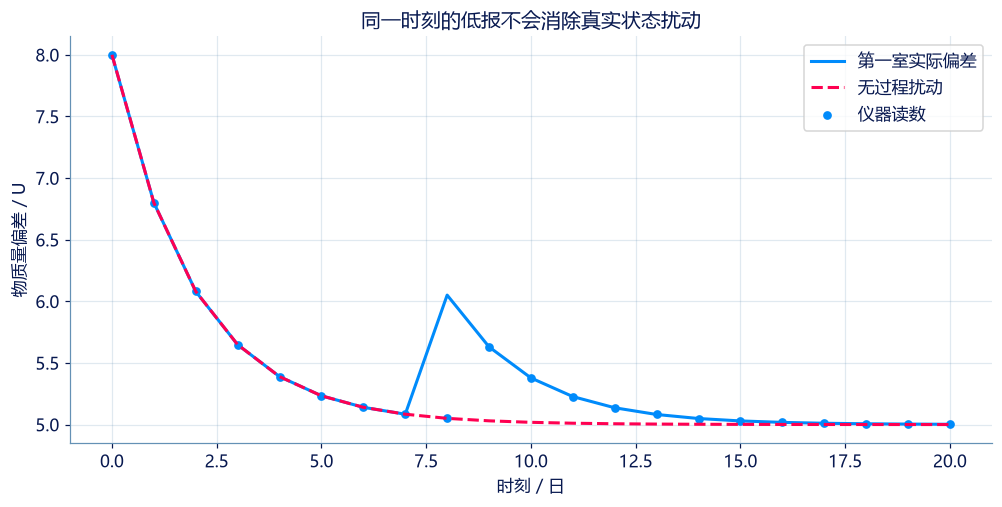

In [4]:
F=[[.8,.2],[.2,.8]];H=[1.,0.];initial=[8.,2.]
increments=np.zeros((20,2));increments[7]=[1.,-1.]
sensor_error=np.zeros(21);sensor_error[8]=-1.
states,observed=state_path(F,H,initial,increments,sensor_error)
baseline,_=state_path(F,H,initial,np.zeros((20,2)),np.zeros(21))
fig,ax=plt.subplots(figsize=(9,4.5));ax.plot(np.array(states)[:,0],label='第一室实际偏差');ax.plot(np.array(baseline)[:,0],'--',label='无过程扰动');ax.scatter(np.arange(21),observed,s=22,label='仪器读数')
ax.set(xlabel='时刻 / 日',ylabel='物质量偏差 / U',title='同一时刻的低报不会消除真实状态扰动');ax.legend();plt.show()

### 独立核验与边界

In [5]:
assert np.allclose(np.array(states).sum(axis=1),10)
assert observed[8]==states[8][0]-1
assert states[9][0]!=baseline[9][0]
print('对称交换和等量反向增量保持总量；测量误差只在读数中出现。')

对称交换和等量反向增量保持总量；测量误差只在读数中出现。


## 结果解释

第8个时刻读数中的负误差可以遮住真实扰动，但后续状态仍携带过程变化。图中“状态”只用于独立核验；后面实现的滤波器只能接收模型、先验（prior）和观测。这个人工偏差模型用来隔离机制，不把交换系数当作人体测量值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：从状态到有噪读数

一个二维状态（state）由给定矩阵（matrix）逐步转移。过程增量改变系统状态，测量误差只改变读数。请按下列时刻约定返回完整状态轨迹（trajectory）与读数。

**函数与代码模板**

```python
def solve(
    transition: list[list[float]],
    sensor: list[float],
    initial: list[float],
    process_noise: list[list[float]],
    measurement_noise: list[float],
) -> tuple[list[list[float]], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `transition` | `list[list[float]]` | 2×2 已知状态转移矩阵（transition matrix）。 | 无量纲 |
| `sensor` | `list[float]` | 长为 2 的观测（observation）行。 | 无量纲 |
| `initial` | `list[float]` | 时刻 0 的两个状态。 | U |
| `process_noise` | `list[list[float]]` | 第 i 项用于时刻 i 到 i+1 的过程增量。 | U |
| `measurement_noise` | `list[float]` | 从时刻 0 开始的测量误差。 | U |

**返回值**

按以下顺序返回元组：(states, observations)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[list[float]]` | 包含初值（initial condition）的 T+1 个状态。 | U |
| `observations` | `list[float]` | H x 加测量误差。 | U |

**计算规则**

x[0]=initial；x[i+1]=F x[i]+process_noise[i]；y[i]=H x[i]+measurement_noise[i]。

**约束与边界**

- F 为 2×2，H 和 initial 长为 2；过程增量 0—20 项；测量误差恰好多 1 项。
- 数值有限，绝对值≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| transition | 2×2 已知状态转移矩阵（transition matrix）。 | [[0.8, 0.2], [0.2, 0.8]] | 无量纲 |
| sensor | 长为 2 的观测（observation）行。 | [1.0, 0.0] | 无量纲 |
| initial | 时刻 0 的两个状态。 | [8.0, 2.0] | U |
| process_noise | 第 i 项用于时刻 i 到 i+1 的过程增量。 | [[0.0, 0.0], [0.1, -0.1]] | U |
| measurement_noise | 从时刻 0 开始的测量误差。 | [0.2, 0.0, -0.2] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
transition = [[0.8, 0.2], [0.2, 0.8]]
sensor = [1.0, 0.0]
initial = [8.0, 2.0]
process_noise = [[0.0, 0.0], [0.1, -0.1]]
measurement_noise = [0.2, 0.0, -0.2]

result = solve(transition, sensor, initial, process_noise, measurement_noise)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 包含初值（initial condition）的 T+1 个状态。 | [[8.0, 2.0], [6.800000000000001, 3.2], [6.1800000000000015, 3.8200000000000007]] | U |
| observations | H x 加测量误差。 | [8.2, 6.800000000000001, 5.980000000000001] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[8.0, 2.0],
                    [6.800000000000001, 3.2],
                    [6.1800000000000015,
                     3.8200000000000007]],
                   [8.2,
                    6.800000000000001,
                    5.980000000000001])
```

**样例解释**

初次读数为8.2，第一次转移后第一室为6.8；测量误差不回写到状态。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：从状态到有噪读数](http://127.0.0.1:8000/chapters/07-01-%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E8%83%BD%E8%A7%82%E6%80%A7/practice/?question=p07-state-readings)

### 第 2 题 · 多项选择题：两种噪声加在哪里

两个组织室中，交换量每天有随机波动；传感器读数还叠加独立误差。哪些表述正确？

- **A.** 过程噪声（process noise）改变后续状态（state）。
- **B.** 测量噪声（measurement noise）必然改变物质收支（mass balance）。
- **C.** 已知模型（model）下，滤波器只能使用给定读数和先验（prior）。
- **D.** 把核验真值作为输入（input）可以公平评价状态恢复。

[作答：两种噪声加在哪里](http://127.0.0.1:8000/chapters/07-01-%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E8%83%BD%E8%A7%82%E6%80%A7/practice/?question=p07-noise-location)

### 第 3 题 · 单项选择题：未知的是哪一类量

已知交换系数与噪声模型（model），只知道两个室物质量的先验（prior）分布（distribution）。根据逐日读数估计两室当前物质量，属于哪项？

- **A.** 参数（parameter）辨识。
- **B.** 状态（state）估计。
- **C.** 系统结构已经被证明正确。
- **D.** 无需观测（observation）的确定性求解。

[作答：未知的是哪一类量](http://127.0.0.1:8000/chapters/07-01-%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E8%83%BD%E8%A7%82%E6%80%A7/practice/?question=p07-state-parameter)

### 第 4 题 · 多项选择题：条件独立的范围

假设 x[t+1]=F x[t]+w[t]，y[t]=H x[t]+v[t]，各时刻 w、v 和 x[0] 相互独立。哪些正确？

- **A.** 给定当前状态（state）后，未来转移与更早状态条件独立（conditional independence）。
- **B.** 所有观测（observation）必然相互独立。
- **C.** 相邻状态一般仍相关。
- **D.** 不必声明噪声假设也可直接套高斯精确结论。

[作答：条件独立的范围](http://127.0.0.1:8000/chapters/07-01-%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E8%83%BD%E8%A7%82%E6%80%A7/practice/?question=p07-independence)

### 延伸阅读

R26，第5章状态空间模型。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-01-状态空间与能观性/explore/) · [本篇目录](../README.md)